# Benchmark: Axisymmetric cooling and spreading

In [1]:
import subprocess
import os
import xarray as xr
import rasterio as rio
from rasterio.enums import Resampling
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import glob
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor


#### This benchmark is a temperature-dependent test on a viscous flow. 

In this experiment, a hot Newtonian fluid is extruded from a point source onto a horizontal plane and allowed to cool to the ambient air temperature. The propogation of such a flow has an analytical solution, which is plotted alongside the models.

We have the initial volume set in accordance with the [Garel et al., 2012](https://appliedvolc.biomedcentral.com/articles/10.1186/s13617-017-0061-x#ref-CR26) experiment.

We encourage changing the volume betweens runs to compare the physical or stochastic reactions at various scales.

In [2]:
volume = 3.432e-6

#### The following cells should not be edited, unless you have extensive knowledge of the model.

The following cell sets up common parameters. Following this, the next 4 cells format and generate input files for each respective model, at parameters considered reasonable for this benchmark.

In [3]:
easting = 0
northing = 0
dem = "DEMs_Lava_Benchmark/Benchmark_Axisymmetric.asc"
raster = rxr.open_rasterio(dem)
raster = raster.sel({"band": 1})
xll, yll = float(raster.x.min()), float(raster.y.min())
coordinates = np.array([int(easting),int(northing)])
r = rio.open(dem)
res = r.res
run_time = 1000
ratio = volume/3.432e-6

output_num = str(int(run_time/100))
out = output_num.zfill(4)

filename, file_extension = os.path.splitext(dem)
file_name = os.path.basename(dem)
file_name = os.path.splitext(file_name)[0]
type_flag = 0 #0 is ascii, 1 is tiff
if file_extension in [".geotiff", ".tiff", ".tif"]:
    type_flag = 1
    asc_name = "".join((file_name, ".asc"))
    raster.rio.to_raster(asc_name)
    # os.remove("".join((asc_name, ".aux.xml")))
    # os.remove("".join((file_name, ".prj")))
    cell_size = open(f"""{asc_name}""","r+")
    info = cell_size.readlines()
    uniform = info[4].split()
    if uniform[0] == 'dx':
        info[4] = f"""cellsize     {int(float(uniform[1]))}\n"""
        info[5] = ""
        cell_size.seek(0)
        cell_size.writelines(info)
        cell_size.truncate()
        cell_size.close()
elif file_extension in [".asc", ".ascii"]:
    type_flag = 0
    tiff_name = "".join((file_name, ".tiff"))
    raster.rio.to_raster(tiff_name)

### Molasses: Additional Notes

Molasses input parameters are stored in `custom_molasses.conf` in the `Molasses` folder. The most impactful change would be that of changing the minimum and maximum residual, as the cellular automata structure will cause a much larger or smaller area to be impacted. As a stochastic model, no physical parameters are used.

In [4]:
os.chdir('/home/jovyan/Lava Benchmark/Molasses')
f = open("custom_molasses.conf","r+")
conf = f.readlines()
conf[2] = f"""MIN_RESIDUAL = {3e-8*ratio}\n"""
conf[3] = f"""MAX_RESIDUAL = {4e-5*ratio}\n"""
conf[4] = f"""MIN_TOTAL_VOLUME = {str(volume)}\n"""
conf[5] = f"""MAX_TOTAL_VOLUME = {str(volume)}\n"""
conf[6] = f"""MIN_PULSE_VOLUME = {float(volume)/100}\n"""
conf[7] = f"""MAX_PULSE_VOLUME = {float(volume)/100}\n"""
conf[10] = f"""DEM_FILE = ../{dem}\n"""
f.seek(0)
f.writelines(conf)
f.truncate()
f.close()

f=open("events.in","w")
f.write(f"""{easting},{northing}""")
f.close()

subprocess.run("molasses custom_molasses.conf",shell=True,stderr=subprocess.DEVNULL)

victor.convert_molasses("molasses_axisymmetric",resolution=res)

Seeding random number generator: 1742564987


               MOLASSES is a lava flow simulator.

Config file: custom_molasses.conf
Reading in Parameters...
             PARENTS = 1                    [assigned]
    ELEVATION_UNCERT = 0                    [assigned]
        MIN_RESIDUAL = 3e-08                [assigned]
        MAX_RESIDUAL = 4e-05                [assigned]
    MIN_TOTAL_VOLUME = 3.432e-06            [assigned]
    MAX_TOTAL_VOLUME = 3.432e-06            [assigned]
    MIN_PULSE_VOLUME = 3.432e-08            [assigned]
    MAX_PULSE_VOLUME = 3.432e-08            [assigned]
                RUNS = 1                    [assigned]
      ASCII_FLOW_MAP = 1                    [assigned]
            DEM_FILE = ../DEMs_Lava_Benchmark/Benchmark_Axisymmetric.asc [assigned]
         EVENTS_FILE = events.in            [assigned]
Nothing missing.

DEM Information [Arc/Info ASCII Grid]:
  File:              ../DEMs_Lava_Benchmark/Benchmark_Axisymmetric.asc
  Lower Left Origin: (-0.08

### MrLavaLoba/Flowy: Additional Notes

MrLavaLoba/Flowy (a drop in C++ replacement) input parameters are stored in `input.toml` in the `flowy` folder. The most impactful changes would be those such as the thickening parameter, lobe exponent, or max slope probability. Other parameters not mentioned will also affect the creation and placement of lobes. As a stochastic model, no physical parameters are specified by the user.

In [8]:
os.chdir('/home/jovyan/Lava Benchmark/flowy')
g=open("input.toml","r+")
inp = g.readlines()
inp[1] = """run_name = 'Axisymmetric'\n"""
inp[6] = f"""source = '../{dem}'\n"""
inp[21] = """vent_flag = 0\n"""
inp[24] = f"""x_vent = [{int(easting)}]\n"""
inp[25] = f"""y_vent = [{int(northing)}]\n"""
inp[63] = f"""total_volume = {volume}\n"""
g.seek(0)
g.writelines(inp)
g.truncate()
g.close()

subprocess.run("./flowy input.toml",shell=True)

Using input file: input.toml
Output directory path set to: ./output
run_name = Axisymmetric_000
total_time = 00h 00m 00.701s
Total number of processed lobes = 99809
n_lobes/ms = 142
Used RNG seed: -134083281


CompletedProcess(args='./flowy input.toml', returncode=0)

In [ ]:
os.chdir('/home/jovyan/Lava Benchmark/IMEX_LavaFlow')
radius = 2e-3/ratio
h=open("IMEX_LavaFlow.inp","r+")
inp = h.readlines()
inp[1] = 'RUN_NAME="Axisymmetric           ",\n'
inp[4] = f""" T_END=  156,\n"""
inp[5] = f""" DT_OUTPUT=  50,\n"""
inp[13] = f""" X0= {xll}D0     ,\n"""
inp[14] = f""" Y0= {yll}D0      ,\n"""
inp[17] = f""" CELL_SIZE = {res[0]}D0 ,\n"""
inp[103] = f"""  X_SOURCE=  {easting}.0D0 ,\n"""
inp[104] = f"""  Y_SOURCE=  {northing}.0D0 ,\n"""
inp[105] = f""" R_SOURCE=  {res[0]*2}     ,\n"""
inp[106] = f""" VEL_SOURCE= {float(volume)/(radius**2*np.pi*156)} \n"""
h.seek(0)
h.writelines(inp)
h.truncate()
h.close()

subprocess.run(f"""ln -s ../{dem} topography_dem.asc""",shell=True)
p = subprocess.Popen(['./IMEX_LavaFlow'], stdin=subprocess.PIPE, shell=True)
p.communicate(input=b'\n')

ln: failed to create symbolic link 'topography_dem.asc': File exists


 ---------------------
 IMEX_LavaFlow 1.0
 ---------------------
 OpenMP program
 Number of threads used           4
 Run name: Axisymmetric                            
 ----- 2D SIMULATION -----
 Ambient density =    1.1763298740177413       (kg/m3)
 CARRIER PHASE: liquid
 Carrier phase kinematic viscosity:  -1.0000000000000000     
 radiative_term_coeff =    2.2680000000000002E-008
 convective_term_coeff =    35.000000000000000     
 Searching for DEM file
 Reading DEM file
 ncols         161
 nrows         161
 Percent Complete: 100.00% 
 IOSTAT=          -1
 thickness_levels          -1
 dyn_pres_levels          -1
 Searching for probes coords
 Source area =   1.2566299915313721E-005  Error =   5.6260512777406291E-006
 Implicit equations =           3

 ******** START COMPUTATION *********

 WRITING Axisymmetric_0000.p_2d                  
 WRITING Axisymmetric_0000.asc                   
 WRITING Axisymmetric_T_0000.asc                 
 WRITING Axisymmetric_T_surf_0000.asc       

In [5]:
scale = ratio

xres, yres = scale, scale

os.chdir('/home/jovyan/Lava Benchmark/lava2d')

with rio.open("flat.tiff") as dataset:
    scale_factor_x = dataset.res[0]/xres
    scale_factor_y = dataset.res[1]/yres

    profile = dataset.profile.copy()
    data = dataset.read(
        out_shape=(
            dataset.count,
            161,
            161
        ),
        resampling=Resampling.nearest
    )

    transform = dataset.transform * dataset.transform.scale(
        (1 / scale_factor_x),
        (1 / scale_factor_y)
    )
    profile.update({"height": data.shape[-2],
                    "width": data.shape[-1],
                   "transform": transform})

with rio.open("../DEMs_Lava_Benchmark/Benchmark_Axisymmetric.tiff", "w", **profile) as dataset:
    dataset.write(data)

r = rxr.open_rasterio("../DEMs_Lava_Benchmark/Benchmark_Axisymmetric.tiff")
lonlat = r.rio.reproject("EPSG:4326")
xmin,ymin,xmax,ymax = lonlat.rio.bounds()
center = float(lonlat[:,80,80].x), float(lonlat[:,80,80].y)

k=open("./input.py","r+")
inp = k.readlines()
inp[4] = '    path_to_dem_file    = ("../DEMs_Lava_Benchmark/Benchmark_Axisymmetric.tiff"),\n'
inp[5] = f"""    Lon_SRC             = {center[0]}, # source longitude\n"""
inp[6] = f"""    Lat_SRC             = {center[1]},    # source latitude\n"""
inp[7] = f"""    Lon_LowerLeft       = {xmin}, # bounding box: lower-left longitude\n"""
inp[8] = f"""    Lat_LowerLeft       = {ymin}, # bounding box: lower-left latitude\n"""
inp[9] = f"""    Lon_UpperRight      = {xmax}, # bounding box: upper-right longitude\n"""
inp[10] = f"""    Lat_UpperRight      = {ymax},   # bounding box: upper-right latitude\n"""
inp[67] = f"""    max_time_hr = {156/3600},\n"""

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

k=open("./example_vents/vent_01.txt","r+")
inp = k.readlines()
inp[1] = f'''0	{-5*scale}	{-5*scale}	{5*scale}	{5*scale}	{3*scale}	{2e-5*scale}\n'''

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

subprocess.run("python input.py", shell=True)

| --- Reading DEM Dataset --- |
| --- Building Modelling Subset --- |
| --- Building Coordinate Transform --- |
| --- Preparing DEM --- |
| --- DEM Preparation Complete --- |
| --- Initializing Model Domain --- |
| --- Beginning Model Evolution --- |
|  Step (sub): 10 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.000 s (par)  |  t: 0.00 hr |
|  Step (sub): 20 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.000 s (par)  |  t: 0.00 hr |
|  Step (sub): 30 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.000 s (par)  |  t: 0.00 hr |
|  Step (sub): 40 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.000 s (par)  |  t: 0.00 hr |
|  Step (sub): 50 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.001 s (par)  |  t: 0.00 hr |
|  Step (sub): 60 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.001 s (par)  |  t: 0.00 hr |
|  Step (sub): 70 (1)  |  dx: 0.125 m  |  Grid: 129 x 129  |  dt (type): 0.001 s (par)  |  t: 0.00 hr |
|  Step (sub): 80 (1)

Traceback (most recent call last):
  File "/home/jovyan/Lava Benchmark/lava2d/input.py", line 84, in <module>
    sim.run()
  File "/home/jovyan/Lava Benchmark/lava2d/sim.py", line 386, in run
    bounds = m.subset_bounds(t_n, buffer_cells = 2*buffer)
  File "/home/jovyan/Lava Benchmark/lava2d/muscl.py", line 79, in subset_bounds
    if ~np.any(I):
  File "/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/core/fromnumeric.py", line 2412, in any
    return _wrapreduction(a, np.logical_or, 'any', axis, None, out,
  File "/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/core/fromnumeric.py", line 88, in _wrapreduction
    return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
data = xr.open_dataset("lava2d/outputs/out.nc",group="DATA/PHYSICS",decode_coords="all")
data = data.where(data!=0, np.nan)

coord = xr.open_dataset("lava2d/outputs/out.nc",group="DATA", decode_coords="all")
lat = coord.lat[:,0]
lon = coord.lon[0,:]
data['rows'] = lat.values
data['cols'] = lon.values
data = data.rename({"rows": "y", "cols": "x"})
repeated_arr_x = np.repeat(data.y.values[0], len(data.x))
repeated_arr_y = np.repeat(data.x.values[0], len(data.y))
data.lava_thickness_total.rio.to_raster("lava2d/axisymmetric_output.tif")

#### The final two cells concern visualization.

The first provides a reference to the final timestamp of each simulation, though all outputs are avilable in their models' respective folder. The second and last cell plots each model side by side. We encourage users to edit this to their personal preference.

In [6]:
os.chdir("/home/jovyan/Lava Benchmark/")

flowy_outputs = glob.glob(f'flowy/output/Axisymmetric*thickness_masked*.asc')
flowy_out = flowy_outputs[-1]

r = rxr.open_rasterio("IMEX_LavaFlow/Axisymmetric_max.asc",masked=True)
r2 = rxr.open_rasterio("Molasses/molasses_axisymmetric.asc",masked=True)
r3 = rxr.open_rasterio(flowy_out,masked=True)
r4 = rxr.open_rasterio("lava2d/axisymmetric_output.tif",masked=True)
r_min, r_max = r.min(), r.max()
r2_min, r2_max = r2.min(), r2.max()
r3_min, r3_max = r3.min(), r3.max()
r4_min, r4_max = r4.min()/1000, r4.max()/1000

maximum = np.max((r_max,r2_max,r3_max,r4_max))
idx_max = np.argmax((r_max,r2_max,r3_max,r4_max))

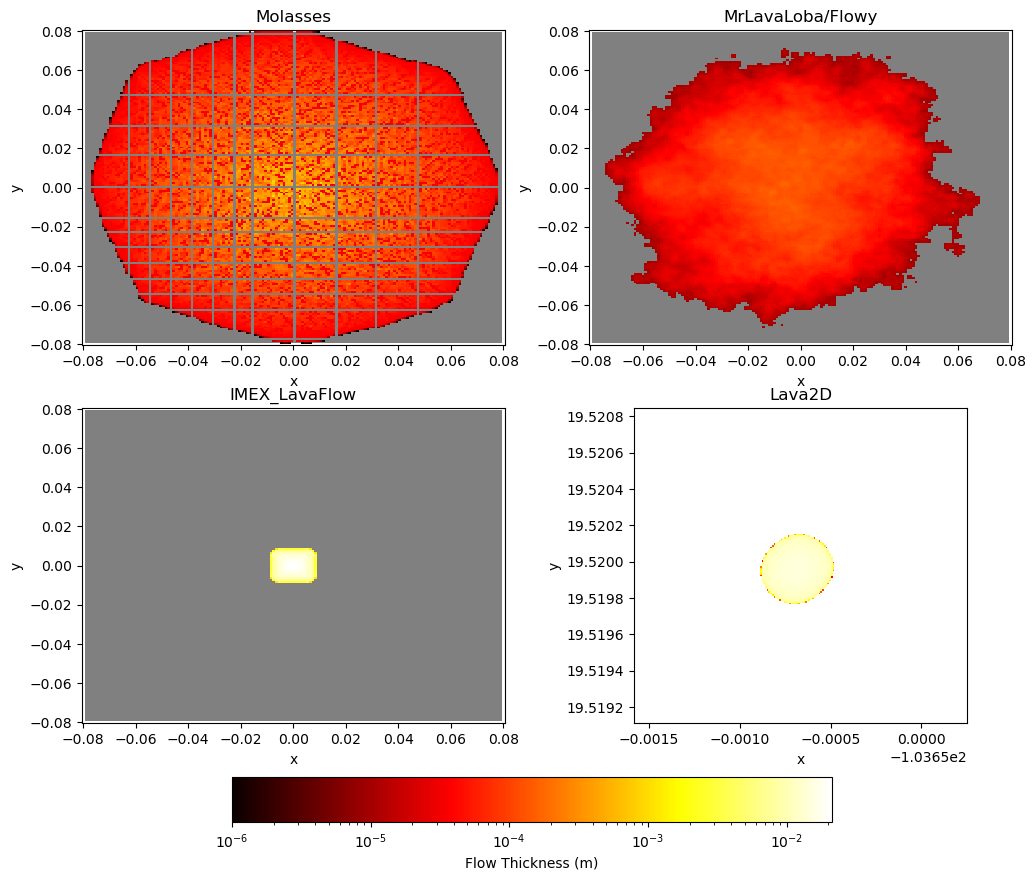

In [29]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2, figsize = (12,9))


thickness0 = victor.plot_flow(dem, "Molasses/molasses_axisymmetric.asc", axes=ax0,zoom=False,title='Molasses',minimum=1e-6,scale=maximum)
thickness1 = victor.plot_flow(dem, flowy_out, axes=ax1, zoom=False,title='MrLavaLoba/Flowy',minimum=1e-6, scale=maximum)
thickness2 = victor.plot_flow(dem, "IMEX_LavaFlow/Axisymmetric_max.asc", axes=ax2, zoom=False,title='IMEX_LavaFlow', minimum=1e-6, scale=maximum)
thickness3 = victor.plot_flow("lava2d/Benchmark_Axisymmetric.tiff", "lava2d/axisymmetric_output.tif", axes=ax3 ,title='Lava2D', minimum=1e-10, scale=maximum*100)

ticks = np.array([-.08, -.04, 0, .04, .08])

# ax3.set_xticks(np.linspace(0,161,5))
# ax3.set_yticks(np.linspace(0,161,5))
# ax3.set_xticklabels(ticks*1000)
# ax3.set_yticklabels(np.array(list(reversed(ticks)))*1000)
ax3.set_aspect("equal")

cbar_ax = fig.add_axes([.25, 0, 0.5, 0.05])
thickness = [thickness0, thickness1, thickness2, thickness3]
thickness = thickness[idx_max]
fig.colorbar(thickness, cax=cbar_ax, label="Flow Thickness (m)", orientation="horizontal")

In [31]:
f = rxr.open_rasterio("DEMs_Lava_Benchmark/Benchmark_Axisymmetric.tiff")
f.rio.resolution()

(0.001, -0.001)